In [1]:
import pandas as pd
airbnb = pd.read_csv("data/airbnb.csv")
airbnb.head(5)

,Unnamed: 0,listing_id,name,host_id,host_name,neighbourhood_full,coordinates,room_type,price,number_of_reviews,last_review,reviews_per_month,availability_365,rating,number_of_stays,5_stars,listing_added
0,0,13740704,"Cozy,budget friendly, cable inc, private entra...",20583125,Michel,"Brooklyn, Flatlands","(40.63222, -73.93398)",Private room,45$,10,2018-12-12,0.70,85,4.100954,12.0,0.609432,2018-06-08
1,1,22005115,Two floor apartment near Central Park,82746113,Cecilia,"Manhattan, Upper West Side","(40.78761, -73.96862)",Entire home/apt,135$,1,2019-06-30,1.00,145,3.367600,1.2,0.746135,2018-12-25
2,2,21667615,Beautiful 1BR in Brooklyn Heights,78251,Leslie,"Brooklyn, Brooklyn Heights","(40.7007, -73.99517)",Entire home/apt,150$,0,NaN,NaN,65,NaN,NaN,NaN,2018-08-15
3,3,6425850,"Spacious, charming studio",32715865,Yelena,"Manhattan, Upper West Side","(40.79169, -73.97498)",Entire home/apt,86$,5,2017-09-23,0.13,0,4.763203,6.0,0.769947,2017-03-20
4,4,22986519,Bedroom on the lively Lower East Side,154262349,Brooke,"Manhattan, Lower East Side","(40.71884, -73.98354)",Private room,160$,23,2019-06-12,2.29,102,3.822591,27.6,0.649383,2020-10-23


In [69]:
airbnb.describe()

,Unnamed: 0,listing_id,host_id,number_of_reviews,reviews_per_month,availability_365,rating,number_of_stays,5_stars
count,10019.000000,1.001900e+04,1.001900e+04,10019.000000,7944.000000,10019.000000,7944.000000,7944.000000,7944.000000
mean,5009.000000,1.927634e+07,6.795923e+07,22.459727,1.353894,112.284260,4.014458,33.991541,0.718599
std,2892.380507,1.095056e+07,7.863106e+07,43.173896,1.615380,131.636043,0.575064,56.089279,0.079978
min,0.000000,3.831000e+03,2.787000e+03,0.000000,0.010000,0.000000,3.000633,1.200000,0.600026
25%,2504.500000,9.674772e+06,7.910880e+06,1.000000,0.200000,0.000000,3.520443,3.600000,0.655576
50%,5009.000000,2.007030e+07,3.165167e+07,5.000000,0.710000,44.000000,4.027965,10.800000,0.709768
75%,7513.500000,2.933864e+07,1.074344e+08,22.000000,2.000000,226.000000,4.516378,38.400000,0.763978
max,10018.000000,3.648724e+07,2.741034e+08,510.000000,16.220000,365.000000,5.181114,612.000000,0.950339


In [70]:
airbnb.isna().sum()

Unnamed: 0               0
listing_id               0
name                     5
host_id                  0
host_name                2
neighbourhood_full       0
coordinates              0
room_type                0
price                  238
number_of_reviews        0
last_review           2075
reviews_per_month     2075
availability_365         0
rating                2075
number_of_stays       2075
5_stars               2075
listing_added            0
dtype: int64

In [71]:
airbnb.shape

(10019, 17)

In [2]:
airbnb['room_type'].drop_duplicates()

0              Private room
1           Entire home/apt
19                  Private
54              Shared room
99             PRIVATE ROOM
271                    home
417       Shared room      
Name: room_type, dtype: object

In [3]:
airbnb['room_type'] = airbnb['room_type'].str.lower()
airbnb['room_type'].drop_duplicates()

0              private room
1           entire home/apt
19                  private
54              shared room
271                    home
417       shared room      
Name: room_type, dtype: object

In [74]:
airbnb['room_type'] = airbnb['room_type'].str.strip()
airbnb['room_type'].drop_duplicates()

0         private room
1      entire home/apt
19             private
54         shared room
271               home
Name: room_type, dtype: object

In [4]:
mappings ={
    'private room': 'private room',
    'private': 'private',
    'entire home/apt': 'entire',
    'shared room': 'shared',
    'home' : 'home'
}

airbnb['room_type'] = airbnb['room_type'].replace(mappings)
airbnb['room_type'].drop_duplicates()

0              private room
1                    entire
19                  private
54                   shared
271                    home
417       shared room      
Name: room_type, dtype: object

In [76]:
airbnb.dtypes

Unnamed: 0              int64
listing_id              int64
name                   object
host_id                 int64
host_name              object
neighbourhood_full     object
coordinates            object
room_type              object
price                  object
number_of_reviews       int64
last_review            object
reviews_per_month     float64
availability_365        int64
rating                float64
number_of_stays       float64
5_stars               float64
listing_added          object
dtype: object

In [5]:
airbnb['room_type'].value_counts()

room_type
entire                  5120
private room            4518
shared                   155
private                   89
   shared room            71
home                      66
Name: count, dtype: int64

In [78]:
import pandas as pd
airbnb = pd.read_csv("data/airbnb.csv")

In [6]:
airbnb['price'] = airbnb['price'].str.strip('$')
airbnb['price'] = airbnb['price'].astype(float)
airbnb.head(5)

,Unnamed: 0,listing_id,name,host_id,host_name,neighbourhood_full,coordinates,room_type,price,number_of_reviews,last_review,reviews_per_month,availability_365,rating,number_of_stays,5_stars,listing_added
0,0,13740704,"Cozy,budget friendly, cable inc, private entra...",20583125,Michel,"Brooklyn, Flatlands","(40.63222, -73.93398)",private room,45.0,10,2018-12-12,0.70,85,4.100954,12.0,0.609432,2018-06-08
1,1,22005115,Two floor apartment near Central Park,82746113,Cecilia,"Manhattan, Upper West Side","(40.78761, -73.96862)",entire,135.0,1,2019-06-30,1.00,145,3.367600,1.2,0.746135,2018-12-25
2,2,21667615,Beautiful 1BR in Brooklyn Heights,78251,Leslie,"Brooklyn, Brooklyn Heights","(40.7007, -73.99517)",entire,150.0,0,NaN,NaN,65,NaN,NaN,NaN,2018-08-15
3,3,6425850,"Spacious, charming studio",32715865,Yelena,"Manhattan, Upper West Side","(40.79169, -73.97498)",entire,86.0,5,2017-09-23,0.13,0,4.763203,6.0,0.769947,2017-03-20
4,4,22986519,Bedroom on the lively Lower East Side,154262349,Brooke,"Manhattan, Lower East Side","(40.71884, -73.98354)",private room,160.0,23,2019-06-12,2.29,102,3.822591,27.6,0.649383,2020-10-23


In [80]:
airbnb.dtypes

Unnamed: 0              int64
listing_id              int64
name                   object
host_id                 int64
host_name              object
neighbourhood_full     object
coordinates            object
room_type              object
price                 float64
number_of_reviews       int64
last_review            object
reviews_per_month     float64
availability_365        int64
rating                float64
number_of_stays       float64
5_stars               float64
listing_added          object
dtype: object

In [7]:
airbnb['listing_added'] = pd.to_datetime(airbnb['listing_added'])
airbnb['last_review'] = pd.to_datetime(airbnb['last_review'])
airbnb['diff'] = airbnb['last_review'] - airbnb['listing_added']
airbnb.head(5)

,Unnamed: 0,listing_id,name,host_id,host_name,neighbourhood_full,coordinates,room_type,price,number_of_reviews,last_review,reviews_per_month,availability_365,rating,number_of_stays,5_stars,listing_added,diff
0,0,13740704,"Cozy,budget friendly, cable inc, private entra...",20583125,Michel,"Brooklyn, Flatlands","(40.63222, -73.93398)",private room,45.0,10,2018-12-12,0.70,85,4.100954,12.0,0.609432,2018-06-08,187 days
1,1,22005115,Two floor apartment near Central Park,82746113,Cecilia,"Manhattan, Upper West Side","(40.78761, -73.96862)",entire,135.0,1,2019-06-30,1.00,145,3.367600,1.2,0.746135,2018-12-25,187 days
2,2,21667615,Beautiful 1BR in Brooklyn Heights,78251,Leslie,"Brooklyn, Brooklyn Heights","(40.7007, -73.99517)",entire,150.0,0,NaT,NaN,65,NaN,NaN,NaN,2018-08-15,NaT
3,3,6425850,"Spacious, charming studio",32715865,Yelena,"Manhattan, Upper West Side","(40.79169, -73.97498)",entire,86.0,5,2017-09-23,0.13,0,4.763203,6.0,0.769947,2017-03-20,187 days
4,4,22986519,Bedroom on the lively Lower East Side,154262349,Brooke,"Manhattan, Lower East Side","(40.71884, -73.98354)",private room,160.0,23,2019-06-12,2.29,102,3.822591,27.6,0.649383,2020-10-23,-499 days


In [82]:
airbnb['room_type'] = airbnb['room_type'].str.lower()

In [83]:
airbnb['room_type'].value_counts()

room_type
entire home/apt         5120
private room            4518
shared room              155
private                   89
   shared room            71
home                      66
Name: count, dtype: int64

In [84]:
airbnb['room_type'] = airbnb['room_type'].str.strip()

In [85]:
mappings = {
    'private room': 'private room',
    'private' : 'private room',
    'entire home/apt': 'entire',
    'shared room': 'shared',
    'home' : 'entire'
}

airbnb['room_type'] = airbnb['room_type'].replace(mappings)
airbnb['room_type'].value_counts()

room_type
entire          5186
private room    4607
shared           226
Name: count, dtype: int64

In [8]:
airbnb[['borough', 'neighbourhood']] = airbnb['neighbourhood_full'].str.split(',', expand=True)
airbnb.head(5)

,Unnamed: 0,listing_id,name,host_id,host_name,neighbourhood_full,coordinates,room_type,price,number_of_reviews,last_review,reviews_per_month,availability_365,rating,number_of_stays,5_stars,listing_added,diff,borough,neighbourhood
0,0,13740704,"Cozy,budget friendly, cable inc, private entra...",20583125,Michel,"Brooklyn, Flatlands","(40.63222, -73.93398)",private room,45.0,10,2018-12-12,0.70,85,4.100954,12.0,0.609432,2018-06-08,187 days,Brooklyn,Flatlands
1,1,22005115,Two floor apartment near Central Park,82746113,Cecilia,"Manhattan, Upper West Side","(40.78761, -73.96862)",entire,135.0,1,2019-06-30,1.00,145,3.367600,1.2,0.746135,2018-12-25,187 days,Manhattan,Upper West Side
2,2,21667615,Beautiful 1BR in Brooklyn Heights,78251,Leslie,"Brooklyn, Brooklyn Heights","(40.7007, -73.99517)",entire,150.0,0,NaT,NaN,65,NaN,NaN,NaN,2018-08-15,NaT,Brooklyn,Brooklyn Heights
3,3,6425850,"Spacious, charming studio",32715865,Yelena,"Manhattan, Upper West Side","(40.79169, -73.97498)",entire,86.0,5,2017-09-23,0.13,0,4.763203,6.0,0.769947,2017-03-20,187 days,Manhattan,Upper West Side
4,4,22986519,Bedroom on the lively Lower East Side,154262349,Brooke,"Manhattan, Lower East Side","(40.71884, -73.98354)",private room,160.0,23,2019-06-12,2.29,102,3.822591,27.6,0.649383,2020-10-23,-499 days,Manhattan,Lower East Side


In [9]:
airbnb['coordinates'] = airbnb['coordinates'].str.strip('(')
airbnb['coordinates'] = airbnb['coordinates'].str.strip(')')
airbnb[['latitude','longitude']] = airbnb['coordinates'].str.split(',',expand = True)
sol = airbnb.drop(columns=['coordinates'])
sol

,Unnamed: 0,listing_id,name,host_id,host_name,neighbourhood_full,room_type,price,number_of_reviews,last_review,...,availability_365,rating,number_of_stays,5_stars,listing_added,diff,borough,neighbourhood,latitude,longitude
0,0,13740704,"Cozy,budget friendly, cable inc, private entra...",20583125,Michel,"Brooklyn, Flatlands",private room,45.0,10,2018-12-12,...,85,4.100954,12.0,0.609432,2018-06-08,187 days,Brooklyn,Flatlands,40.63222,-73.93398
1,1,22005115,Two floor apartment near Central Park,82746113,Cecilia,"Manhattan, Upper West Side",entire,135.0,1,2019-06-30,...,145,3.367600,1.2,0.746135,2018-12-25,187 days,Manhattan,Upper West Side,40.78761,-73.96862
2,2,21667615,Beautiful 1BR in Brooklyn Heights,78251,Leslie,"Brooklyn, Brooklyn Heights",entire,150.0,0,NaT,...,65,NaN,NaN,NaN,2018-08-15,NaT,Brooklyn,Brooklyn Heights,40.7007,-73.99517
3,3,6425850,"Spacious, charming studio",32715865,Yelena,"Manhattan, Upper West Side",entire,86.0,5,2017-09-23,...,0,4.763203,6.0,0.769947,2017-03-20,187 days,Manhattan,Upper West Side,40.79169,-73.97498
4,4,22986519,Bedroom on the lively Lower East Side,154262349,Brooke,"Manhattan, Lower East Side",private room,160.0,23,2019-06-12,...,102,3.822591,27.6,0.649383,2020-10-23,-499 days,Manhattan,Lower East Side,40.71884,-73.98354
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10014,10014,22307861,Lovely 1BR Harlem apartment,16004068,Rachel,"Manhattan, Harlem",entire,105.0,4,2018-05-28,...,0,4.757555,4.8,0.639223,2017-11-22,187 days,Manhattan,Harlem,40.80379,-73.95257
10015,10015,953275,Apartment For Your Holidays in NYC!,4460034,Alain,"Manhattan, East Harlem",entire,125.0,50,2018-05-06,...,188,4.344704,60.0,0.648778,2017-10-31,187 days,Manhattan,East Harlem,40.79531,-73.9333
10016,10016,3452835,"Artsy, Garden Getaway in Central Brooklyn",666862,Amy,"Brooklyn, Clinton Hill",entire,100.0,45,2016-11-27,...,0,3.966214,54.0,0.631713,2016-05-24,187 days,Brooklyn,Clinton Hill,40.68266,-73.96743000000002
10017,10017,23540194,"Immaculate townhouse in Clinton Hill, Brooklyn",67176930,Sophie,"Brooklyn, Clinton Hill",entire,450.0,2,2019-05-31,...,99,4.078581,2.4,0.703360,2018-11-25,187 days,Brooklyn,Clinton Hill,40.68832,-73.96366


In [10]:
airbnb.drop(columns=['Unnamed: 0'], inplace=True)

In [89]:
#airbnb['price'] = airbnb['price'].str.strip('$').astype(float)
#airbnb.dtypes

AttributeError: Can only use .str accessor with string values!

In [90]:
airbnb['price'].head(5)

0     45.0
1    135.0
2    150.0
3     86.0
4    160.0
Name: price, dtype: float64

In [91]:
airbnb[['borough','neighbourhood']] = airbnb['neighbourhood_full'].str.split(',' , expand = True)
airbnb.head(5)

,listing_id,name,host_id,host_name,neighbourhood_full,coordinates,room_type,price,number_of_reviews,last_review,...,availability_365,rating,number_of_stays,5_stars,listing_added,diff,borough,neighbourhood,latitude,longitude
0,13740704,"Cozy,budget friendly, cable inc, private entra...",20583125,Michel,"Brooklyn, Flatlands","40.63222, -73.93398",private room,45.0,10,2018-12-12,...,85,4.100954,12.0,0.609432,2018-06-08,187 days,Brooklyn,Flatlands,40.63222,-73.93398
1,22005115,Two floor apartment near Central Park,82746113,Cecilia,"Manhattan, Upper West Side","40.78761, -73.96862",entire,135.0,1,2019-06-30,...,145,3.367600,1.2,0.746135,2018-12-25,187 days,Manhattan,Upper West Side,40.78761,-73.96862
2,21667615,Beautiful 1BR in Brooklyn Heights,78251,Leslie,"Brooklyn, Brooklyn Heights","40.7007, -73.99517",entire,150.0,0,NaT,...,65,NaN,NaN,NaN,2018-08-15,NaT,Brooklyn,Brooklyn Heights,40.7007,-73.99517
3,6425850,"Spacious, charming studio",32715865,Yelena,"Manhattan, Upper West Side","40.79169, -73.97498",entire,86.0,5,2017-09-23,...,0,4.763203,6.0,0.769947,2017-03-20,187 days,Manhattan,Upper West Side,40.79169,-73.97498
4,22986519,Bedroom on the lively Lower East Side,154262349,Brooke,"Manhattan, Lower East Side","40.71884, -73.98354",private room,160.0,23,2019-06-12,...,102,3.822591,27.6,0.649383,2020-10-23,-499 days,Manhattan,Lower East Side,40.71884,-73.98354


In [92]:
airbnb['last_review'] = pd.to_datetime(airbnb['last_review'])
airbnb['listing_added'] = pd.to_datetime(airbnb['listing_added'])
airbnb['diff'] = airbnb['listing_added'] - airbnb['last_review']
airbnb.head(5)

,listing_id,name,host_id,host_name,neighbourhood_full,coordinates,room_type,price,number_of_reviews,last_review,...,availability_365,rating,number_of_stays,5_stars,listing_added,diff,borough,neighbourhood,latitude,longitude
0,13740704,"Cozy,budget friendly, cable inc, private entra...",20583125,Michel,"Brooklyn, Flatlands","40.63222, -73.93398",private room,45.0,10,2018-12-12,...,85,4.100954,12.0,0.609432,2018-06-08,-187 days,Brooklyn,Flatlands,40.63222,-73.93398
1,22005115,Two floor apartment near Central Park,82746113,Cecilia,"Manhattan, Upper West Side","40.78761, -73.96862",entire,135.0,1,2019-06-30,...,145,3.367600,1.2,0.746135,2018-12-25,-187 days,Manhattan,Upper West Side,40.78761,-73.96862
2,21667615,Beautiful 1BR in Brooklyn Heights,78251,Leslie,"Brooklyn, Brooklyn Heights","40.7007, -73.99517",entire,150.0,0,NaT,...,65,NaN,NaN,NaN,2018-08-15,NaT,Brooklyn,Brooklyn Heights,40.7007,-73.99517
3,6425850,"Spacious, charming studio",32715865,Yelena,"Manhattan, Upper West Side","40.79169, -73.97498",entire,86.0,5,2017-09-23,...,0,4.763203,6.0,0.769947,2017-03-20,-187 days,Manhattan,Upper West Side,40.79169,-73.97498
4,22986519,Bedroom on the lively Lower East Side,154262349,Brooke,"Manhattan, Lower East Side","40.71884, -73.98354",private room,160.0,23,2019-06-12,...,102,3.822591,27.6,0.649383,2020-10-23,499 days,Manhattan,Lower East Side,40.71884,-73.98354


In [11]:
grouped = airbnb.groupby('room_type')['price'].transform('mean')
airbnb['price'] = airbnb['price'].fillna(grouped)
airbnb['price'].isna().sum()

np.int64(0)

In [94]:
prices = airbnb.groupby('borough')['price'].mean()
sort = prices.sort_values(ascending=False)
sort

borough
Manhattan        193.338269
Brooklyn         123.833108
Queens            97.832053
Staten Island     93.023971
Bronx             89.194180
Name: price, dtype: float64

In [95]:
step  = airbnb.groupby('host_id')['number_of_reviews'].sum()
sorted = step.sort_values(ascending = False)
sorted

host_id
344035       896
9284163      648
47351539     641
40176101     582
303939       538
            ... 
67471774       0
67567916       0
67651553       0
67739226       0
274103383      0
Name: number_of_reviews, Length: 8921, dtype: int64

In [96]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as ss
import seaborn as sns

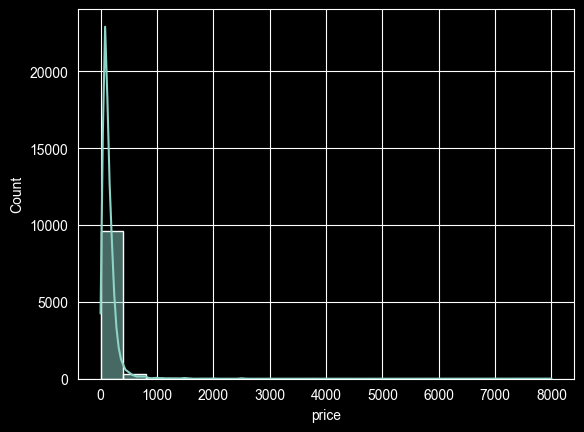

In [97]:
sns.histplot(airbnb['price'], kde=True, bins=20)
plt.show()

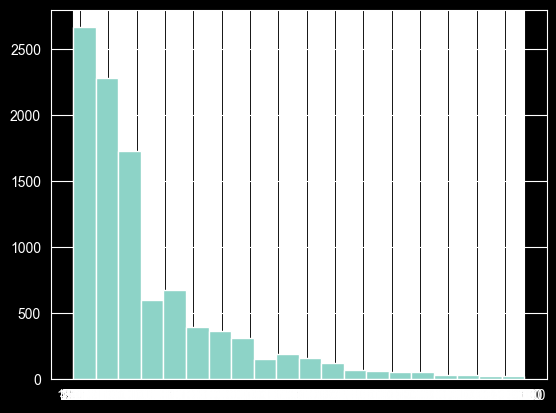

In [98]:
airbnb['price'] = airbnb['price'].astype(str)
p = plt.hist(airbnb['price'], bins=20)


In [99]:
#airbnb['logprice'] = np.log10(airbnb['price'])
#sns.histplot(airbnb['logprice'], kde=True, bins=20, alpha=1)
#plt.show()

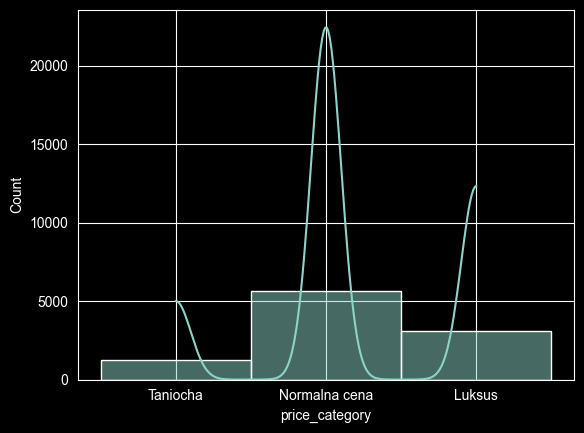

In [100]:
airbnb['price'] = airbnb['price'].astype(str).str.replace('$', '').astype(float)
moje_granice = [0, 50, 150, float('inf')]
moje_nazwy = ['Taniocha', 'Normalna cena', 'Luksus']

airbnb['price_category'] = pd.cut(airbnb['price'], bins=moje_granice, labels=moje_nazwy)
sns.histplot(airbnb['price_category'], kde=True)
plt.show()

In [101]:
airbnb['price_category'].value_counts()

price_category
Normalna cena    5652
Luksus           3105
Taniocha         1260
Name: count, dtype: int64

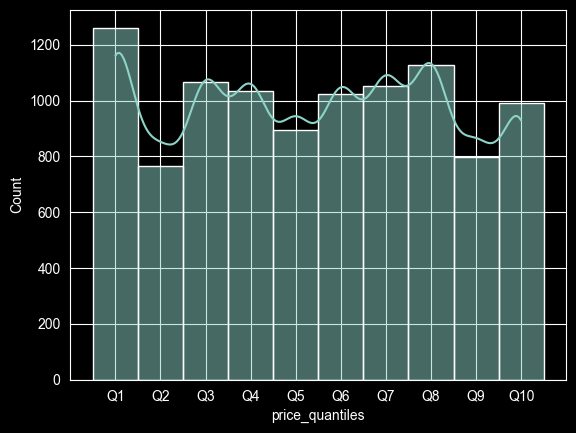

In [102]:
airbnb['price_quantiles'] = pd.qcut(airbnb['price'], q=10, labels=['Q1', 'Q2', 'Q3', 'Q4','Q5','Q6','Q7','Q8','Q9','Q10'])
sns.histplot(airbnb['price_quantiles'], kde=True)
plt.show()

In [103]:
airbnb['price_category'].value_counts(normalize =True)

price_category
Normalna cena    0.564241
Luksus           0.309973
Taniocha         0.125786
Name: proportion, dtype: float64

In [104]:
airbnb['price_category'].value_counts()

price_category
Normalna cena    5652
Luksus           3105
Taniocha         1260
Name: count, dtype: int64

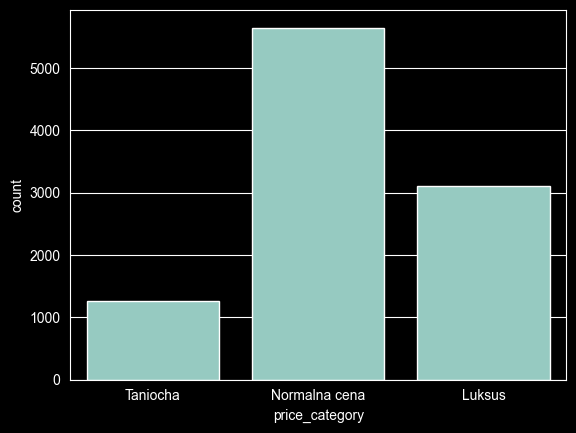

In [105]:
czestotliwosc = airbnb['price_category'].value_counts().reset_index()

sns.barplot(data=czestotliwosc, x='price_category', y='count')

plt.show()

In [14]:
mappings ={
    'private room': 'private room',
    'private': 'private room',
    'entire home/apt': 'entire',
    'shared room': 'shared',
    'home' : 'entire'
}

airbnb['room_type'] = airbnb['room_type'].str.lower().str.strip().replace(mappings)

In [13]:

airbnb['room_type'].drop_duplicates()

sns.barplot(data=airbnb, x='room_type', y='price', hue='room_type', palette='Set2')

plt.show()

NameError: name 'sns' is not defined

In [107]:
import pandas as pd
airbnb = pd.read_csv("data/airbnb.csv")

In [108]:
airbnb.head()

,Unnamed: 0,listing_id,name,host_id,host_name,neighbourhood_full,coordinates,room_type,price,number_of_reviews,last_review,reviews_per_month,availability_365,rating,number_of_stays,5_stars,listing_added
0,0,13740704,"Cozy,budget friendly, cable inc, private entra...",20583125,Michel,"Brooklyn, Flatlands","(40.63222, -73.93398)",Private room,45$,10,2018-12-12,0.70,85,4.100954,12.0,0.609432,2018-06-08
1,1,22005115,Two floor apartment near Central Park,82746113,Cecilia,"Manhattan, Upper West Side","(40.78761, -73.96862)",Entire home/apt,135$,1,2019-06-30,1.00,145,3.367600,1.2,0.746135,2018-12-25
2,2,21667615,Beautiful 1BR in Brooklyn Heights,78251,Leslie,"Brooklyn, Brooklyn Heights","(40.7007, -73.99517)",Entire home/apt,150$,0,NaN,NaN,65,NaN,NaN,NaN,2018-08-15
3,3,6425850,"Spacious, charming studio",32715865,Yelena,"Manhattan, Upper West Side","(40.79169, -73.97498)",Entire home/apt,86$,5,2017-09-23,0.13,0,4.763203,6.0,0.769947,2017-03-20
4,4,22986519,Bedroom on the lively Lower East Side,154262349,Brooke,"Manhattan, Lower East Side","(40.71884, -73.98354)",Private room,160$,23,2019-06-12,2.29,102,3.822591,27.6,0.649383,2020-10-23


In [109]:
airbnb.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10019 entries, 0 to 10018
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Unnamed: 0          10019 non-null  int64  
 1   listing_id          10019 non-null  int64  
 2   name                10014 non-null  object 
 3   host_id             10019 non-null  int64  
 4   host_name           10017 non-null  object 
 5   neighbourhood_full  10019 non-null  object 
 6   coordinates         10019 non-null  object 
 7   room_type           10019 non-null  object 
 8   price               9781 non-null   object 
 9   number_of_reviews   10019 non-null  int64  
 10  last_review         7944 non-null   object 
 11  reviews_per_month   7944 non-null   float64
 12  availability_365    10019 non-null  int64  
 13  rating              7944 non-null   float64
 14  number_of_stays     7944 non-null   float64
 15  5_stars             7944 non-null   float64
 16  list

In [110]:
airbnb['price'] = airbnb['price'].str.strip('$').astype(float)
airbnb.dtypes

Unnamed: 0              int64
listing_id              int64
name                   object
host_id                 int64
host_name              object
neighbourhood_full     object
coordinates            object
room_type              object
price                 float64
number_of_reviews       int64
last_review            object
reviews_per_month     float64
availability_365        int64
rating                float64
number_of_stays       float64
5_stars               float64
listing_added          object
dtype: object

In [111]:
airbnb['coordinates'] = airbnb['coordinates'].str.strip('(')
airbnb['coordinates'] = airbnb['coordinates'].str.strip(')')
airbnb[['x','y']] = airbnb['coordinates'].str.split(',', expand=True)
airbnb.head(5)

,Unnamed: 0,listing_id,name,host_id,host_name,neighbourhood_full,coordinates,room_type,price,number_of_reviews,last_review,reviews_per_month,availability_365,rating,number_of_stays,5_stars,listing_added,x,y
0,0,13740704,"Cozy,budget friendly, cable inc, private entra...",20583125,Michel,"Brooklyn, Flatlands","40.63222, -73.93398",Private room,45.0,10,2018-12-12,0.70,85,4.100954,12.0,0.609432,2018-06-08,40.63222,-73.93398
1,1,22005115,Two floor apartment near Central Park,82746113,Cecilia,"Manhattan, Upper West Side","40.78761, -73.96862",Entire home/apt,135.0,1,2019-06-30,1.00,145,3.367600,1.2,0.746135,2018-12-25,40.78761,-73.96862
2,2,21667615,Beautiful 1BR in Brooklyn Heights,78251,Leslie,"Brooklyn, Brooklyn Heights","40.7007, -73.99517",Entire home/apt,150.0,0,NaN,NaN,65,NaN,NaN,NaN,2018-08-15,40.7007,-73.99517
3,3,6425850,"Spacious, charming studio",32715865,Yelena,"Manhattan, Upper West Side","40.79169, -73.97498",Entire home/apt,86.0,5,2017-09-23,0.13,0,4.763203,6.0,0.769947,2017-03-20,40.79169,-73.97498
4,4,22986519,Bedroom on the lively Lower East Side,154262349,Brooke,"Manhattan, Lower East Side","40.71884, -73.98354",Private room,160.0,23,2019-06-12,2.29,102,3.822591,27.6,0.649383,2020-10-23,40.71884,-73.98354


In [112]:
airbnb['listing_added'] = pd.to_datetime(airbnb['listing_added'])
airbnb['last_review'] = pd.to_datetime(airbnb['last_review'])
airbnb['diff'] = airbnb['listing_added'] - airbnb['last_review']
airbnb.dtypes

Unnamed: 0                      int64
listing_id                      int64
name                           object
host_id                         int64
host_name                      object
neighbourhood_full             object
coordinates                    object
room_type                      object
price                         float64
number_of_reviews               int64
last_review            datetime64[ns]
reviews_per_month             float64
availability_365                int64
rating                        float64
number_of_stays               float64
5_stars                       float64
listing_added          datetime64[ns]
x                              object
y                              object
diff                  timedelta64[ns]
dtype: object

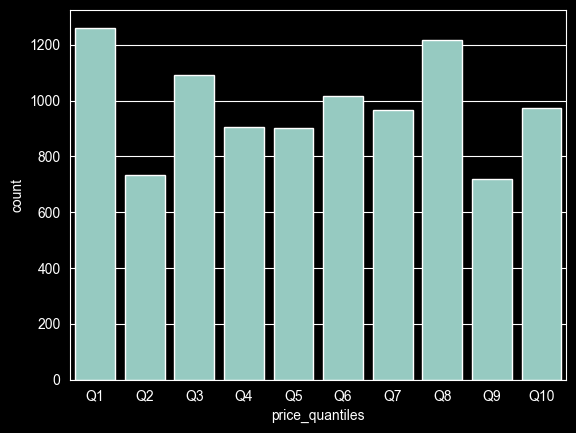

In [113]:
airbnb['price_quantiles'] = pd.qcut(airbnb['price'], q=10, labels=['Q1', 'Q2', 'Q3', 'Q4','Q5','Q6','Q7','Q8','Q9','Q10'])

sns.countplot(data=airbnb, x='price_quantiles')

plt.show()

/Users/adam/PycharmProjects/Data_Analysis_Workshops/.venv/lib/python3.9/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


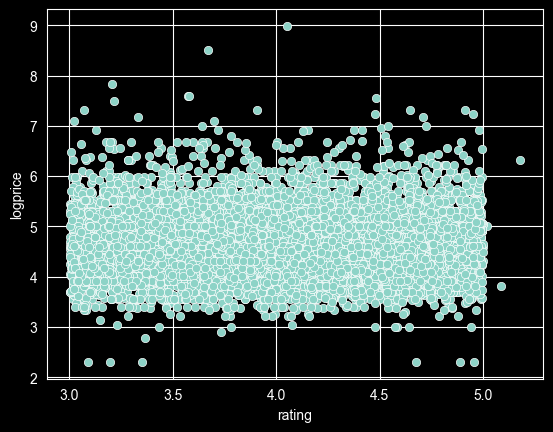

In [126]:
#scatter plot

airbnb['logprice'] = np.log(airbnb['price'])
sns.scatterplot(data=airbnb, x='rating', y='logprice')
plt.show()

In [15]:
airbnb.groupby('room_type')['price'].describe()

,count,mean,std,min,25%,50%,75%,max
room_type,,,,,,,,
entire,5186.0,209.715420,248.824191,0.0,120.0,165.0,225.0,8000.0
private room,4607.0,88.016126,107.425943,0.0,53.0,70.0,95.0,2850.0
shared,226.0,70.387707,127.243165,10.0,35.0,50.0,75.0,1800.0


In [17]:
median = airbnb.groupby('room_type')['price'].median()
median

room_type
entire          165.0
private room     70.0
shared           50.0
Name: price, dtype: float64

<Axes: xlabel='room_type', ylabel='log_price'>

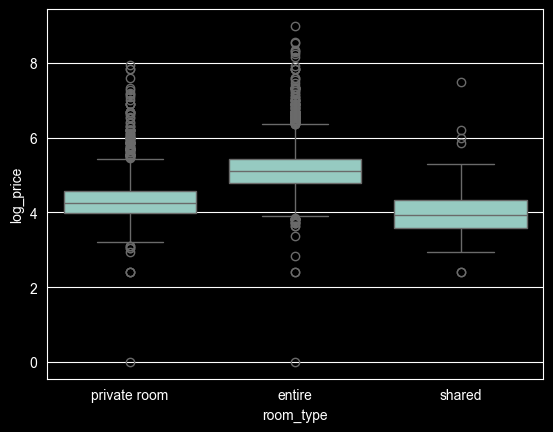

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

airbnb['log_price'] = np.log1p(airbnb['price'])

sns.boxplot(data=airbnb, x='room_type', y='log_price')